# 02 · Insights & EDA

Before any modelling, the goal here is to **understand what drives listing-day gains**. I do a tiny
bit of GMP cleanup inline (just enough to plot it honestly), then look at four things:

1. How listing gains are distributed, and how they changed year by year.
2. Which features actually correlate with the gain.
3. The single most important relationship: **GMP vs listing gain**.
4. A finance-side reality check: even when gains look big, the **allotment lottery** eats most of the
   expected profit for a retail investor.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROC = "../data/processed"
target = "listing_gain_close_pct"

df = pd.read_csv(f"{PROC}/ipo_main.csv")
print("shape:", df.shape)
df[["company", "year", "issue_price", target]].head()


shape: (312, 39)


,company,year,issue_price,listing_gain_close_pct
0,Abans HoldingsIPO,2022,270.0,-4.44
1,Adani WilmarIPO,2022,230.0,16.63
2,Aether IndustriesIPO,2022,642.0,20.62
3,AGS Transact TechnologiesIPO,2022,175.0,-12.00
4,Archean Chemical IndustriesIPO,2022,407.0,21.13


## 1. Light GMP cleanup

The file stores GMP twice — in rupees (`gmp_dayN_rs`) and as a percent (`gmp_dayN_pct`). The two
disagree on many rows. The rupee value is the more reliable one, so I **recompute the percent myself**
from rupees and issue price, and drop any row where a day's GMP is above 200% (clearly a data error).


In [2]:
# recompute a clean GMP% for each of the 5 days from the rupee value
for d in range(1, 6):
    df[f"gmp_day{d}_pct"] = (df[f"gmp_day{d}_rs"] / df["issue_price"] * 100).round(2)

# drop rows where any day is an impossible >200%
bad = pd.Series(False, index=df.index)
for d in range(1, 6):
    bad = bad | (df[f"gmp_day{d}_pct"] > 200)

print("dropping", bad.sum(), "bad rows")
df = df[~bad].reset_index(drop=True)
print("rows left:", len(df))


dropping 3 bad rows
rows left: 309


## 2. The distribution of listing gains, and the year-by-year story

This is the most important chart in the whole project.


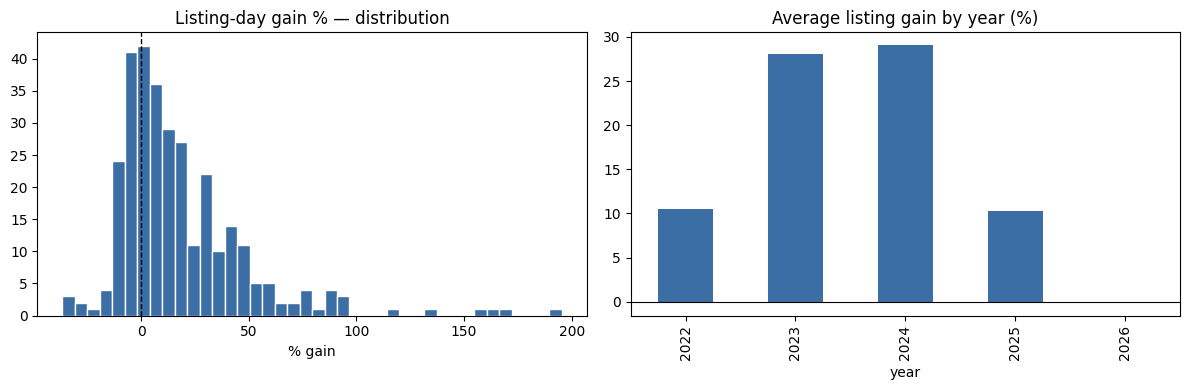

year
2022    10.5
2023    28.0
2024    29.1
2025    10.2
2026    -0.1
Name: listing_gain_close_pct, dtype: float64

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df[target], bins=40, color="#3b6ea5", edgecolor="white")
ax[0].axvline(0, color="k", ls="--", lw=1)
ax[0].set_title("Listing-day gain % — distribution")
ax[0].set_xlabel("% gain")

df.groupby("year")[target].mean().plot(kind="bar", color="#3b6ea5", ax=ax[1])
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("Average listing gain by year (%)")

plt.tight_layout(); plt.show()
df.groupby("year")[target].mean().round(1)


**The key insight.** 2023–24 were red-hot (average pop ~28%), then the market cooled and 2026 is
near zero. This single fact drives the whole modelling strategy later: a model trained on the hot
years will *over-predict* the cooled ones, so I cannot test it with a naive random split — I have to
train on the past and predict the future.


## 3. What correlates with the gain?

A quick correlation of every numeric feature against the listing gain. I sort it so the strongest
positive and negative drivers stand out.


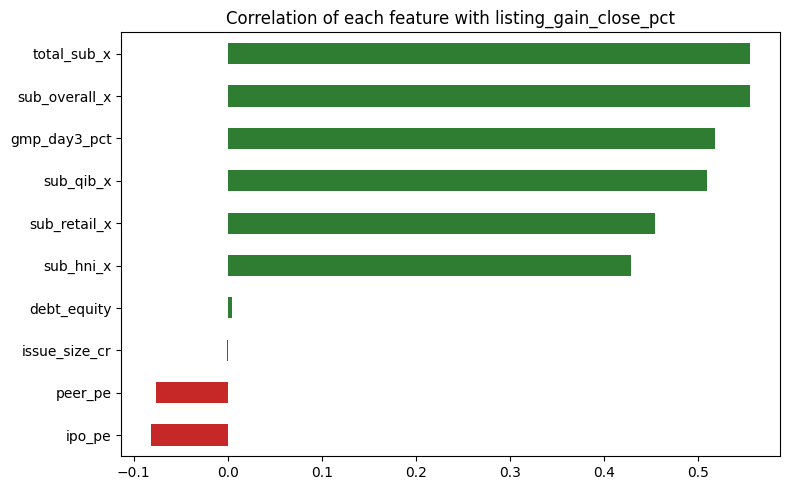

ipo_pe          -0.08
peer_pe         -0.08
issue_size_cr   -0.00
debt_equity      0.00
sub_hni_x        0.43
sub_retail_x     0.45
sub_qib_x        0.51
gmp_day3_pct     0.52
sub_overall_x    0.56
total_sub_x      0.56
Name: listing_gain_close_pct, dtype: float64

In [4]:
num_cols = ["gmp_day3_pct", "total_sub_x", "sub_qib_x", "sub_hni_x", "sub_retail_x",
            "sub_overall_x", "issue_size_cr", "ipo_pe", "peer_pe", "debt_equity", target]

corr = df[num_cols].corr()[target].drop(target).sort_values()

plt.figure(figsize=(8, 5))
colors = np.where(corr > 0, "#2e7d32", "#c62828")
corr.plot(kind="barh", color=colors)
plt.title(f"Correlation of each feature with {target}")
plt.tight_layout(); plt.show()
corr.round(2)


**Reading it:** GMP and subscription strength (especially QIB and overall) carry almost all the
signal. Valuation and leverage (PE, debt/equity) barely move the listing-day gain on their own — the
listing pop is about *demand and market mood*, not the balance sheet. That is why I drop the
fundamentals from the model in notebook 03.


## 4. GMP vs listing gain — the strongest single relationship

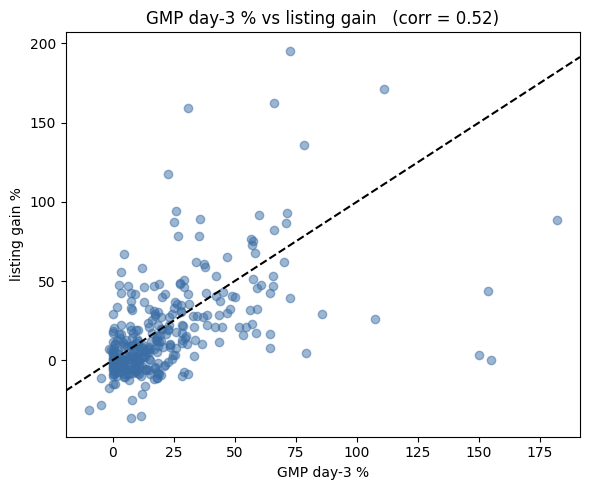

In [5]:
r = df["gmp_day3_pct"].corr(df[target])

plt.figure(figsize=(6, 5))
plt.scatter(df["gmp_day3_pct"], df[target], alpha=0.5, color="#3b6ea5")
plt.axline((0, 0), slope=1, ls="--", color="k")   # the 45-degree "GMP = gain" line
plt.title(f"GMP day-3 % vs listing gain   (corr = {r:.2f})")
plt.xlabel("GMP day-3 %"); plt.ylabel("listing gain %")
plt.tight_layout(); plt.show()


Points hug the 45° line but sit **below** it in the cooled years — the grey market kept quoting
hot-market premiums after the market had already cooled. So GMP has the *direction* right but the
*scale* wrong. Fixing that miscalibration is exactly what the model adds in notebook 05.


## 5. Finance reality check — the allotment lottery

A retail "out-of-the-box" insight that a pure ML view misses. If an IPO is oversubscribed 20×, a
retail applicant only gets shares about **1 in 20** times. So the gain you can *expect* is the listing
gain **times your chance of allotment**. The hottest IPOs (biggest gains) are also the hardest to get.


In [6]:
# chance of allotment ~ 1 / retail subscription (capped at 1 when undersubscribed)
df["p_allot"] = 1 / df["sub_retail_x"].clip(lower=1)

simple_avg = df[target].mean()
allot_weighted = (df["p_allot"] * df[target]).sum() / df["p_allot"].sum()

print(f"simple average listing gain      : {simple_avg:5.1f}%")
print(f"allotment-weighted average gain  : {allot_weighted:5.1f}%")
print("=> once you account for the lottery, the gain you can actually expect is far smaller.")


simple average listing gain      :  18.3%
allotment-weighted average gain  :   5.3%
=> once you account for the lottery, the gain you can actually expect is far smaller.


In [7]:
# group IPOs by how hot the GMP was, and show gain vs how easy allotment is
df["gmp_bucket"] = pd.cut(df["gmp_day3_pct"], [-10, 0, 5, 15, 30, 60, 200],
                          labels=["<0%", "0-5%", "5-15%", "15-30%", "30-60%", ">60%"])

tab = df.groupby("gmp_bucket", observed=True).agg(
    n=("company", "count"),
    avg_gain=(target, "mean"),
    avg_allot_chance=("p_allot", "mean"),
).round(2)
tab


,n,avg_gain,avg_allot_chance
gmp_bucket,,,
<0%,25,-1.15,0.60
0-5%,47,6.58,0.68
5-15%,88,4.96,0.31
15-30%,80,19.70,0.12
30-60%,47,40.85,0.04
>60%,22,65.32,0.24


The hotter the GMP bucket, the bigger the average gain — but the smaller your chance of actually
getting allotted. That tension is the real story for a retail investor, and it is why the project
later builds a separate **retail-decision model**, not just an academic one.

Next: notebook 03 turns all of this into a clean, model-ready feature table.
